# 01 — Signals & Sampling

**Topic:** What is a signal, how is it represented, and how do computers capture it?  
**Applies to:** RF, Audio, Images, ECG, Vibration — any field that processes real-world data  
**Blog:** Week 1 — Signals & Sampling

## 1. What is a Signal?

A signal is any quantity that **varies with respect to an independent variable**.

In most engineering fields that variable is **time**. The signal records how something 
changes — air pressure, voltage, electromagnetic field strength — moment by moment.

In DSP we write it as:

- **x(t)** — continuous time signal, defined at every instant
- **x[n]** — discrete time signal, defined only at specific sampled moments

The physical world is continuous. Computers are discrete.  
The bridge between them is **sampling**.

## 2. The Sine Wave

The sine wave is the fundamental building block of all signals.  
Any signal — no matter how complex — can be broken down into sine waves.  
This is the foundation of the Fourier Transform, covered in notebook 03.

A sine wave is fully described by three properties:

| Property | Symbol | Unit | Meaning |
|---|---|---|---|
| Amplitude | A | Volts | Peak height of the wave |
| Frequency | f | Hz | Cycles per second |
| Phase | φ | Degrees or Radians | Starting position in the cycle |

### Equation

$$x(t) = A \cdot \sin(2\pi f t + \varphi)$$

Where:
- $2\pi f$ converts frequency in Hz to angular frequency in radians per second
- $t$ is time in seconds
- $\varphi$ is phase offset in radians

### Period

The period T is the time for one complete cycle:

$$T = \frac{1}{f}$$

| Frequency | Period | Context |
|---|---|---|
| 1 Hz | 1 s | Sensor / baseband |
| 1 kHz | 1 ms | Audio |
| 1 MHz | 1 µs | AM Radio |
| 1 GHz | 1 ns | LTE / WiFi / Bluetooth |
| 2.4 GHz | 0.417 ns | Bluetooth / WiFi |

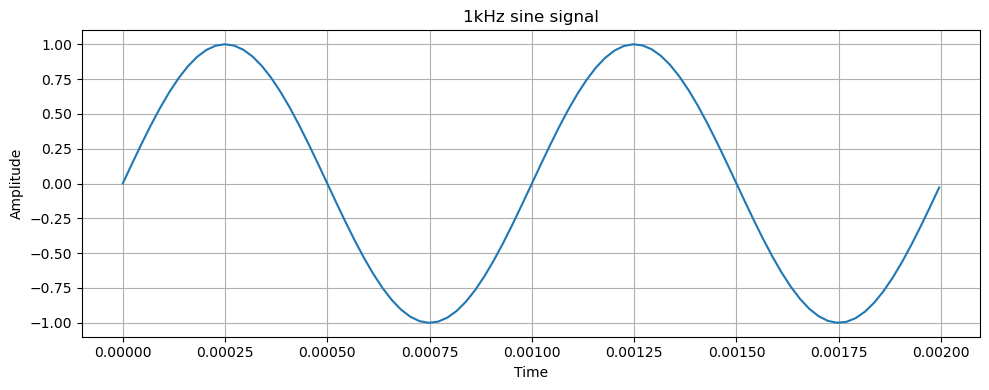

In [8]:
import sys
import os

# Add the parent directory (Rf-Lab) to sys.path
sys.path.append(os.path.abspath('..'))

from core.signal_generator import SignalGenerator
from utils.plotter import Plotter

import matplotlib.pyplot as plt
import numpy as np


# 1 kHz sine wave at amplitude 1, duration 0.002 seconds, using SignalGenerator.

sg = SignalGenerator(fs=44100)

t, sine = sg.sine(frequency=1000, amplitude=1, duration=0.002)

Plotter.plot_time(t, signal=sine, title="1kHz sine signal", xlabel="Time", ylabel="Amplitude")

## 3. Effect of Each Parameter

Before sampling, let's build intuition for what each parameter does visually.

- **Amplitude** controls the height — scale the wave up or down
- **Frequency** controls how many cycles fit in the window — higher = more compressed
- **Phase** shifts the wave left or right — same shape, different starting point

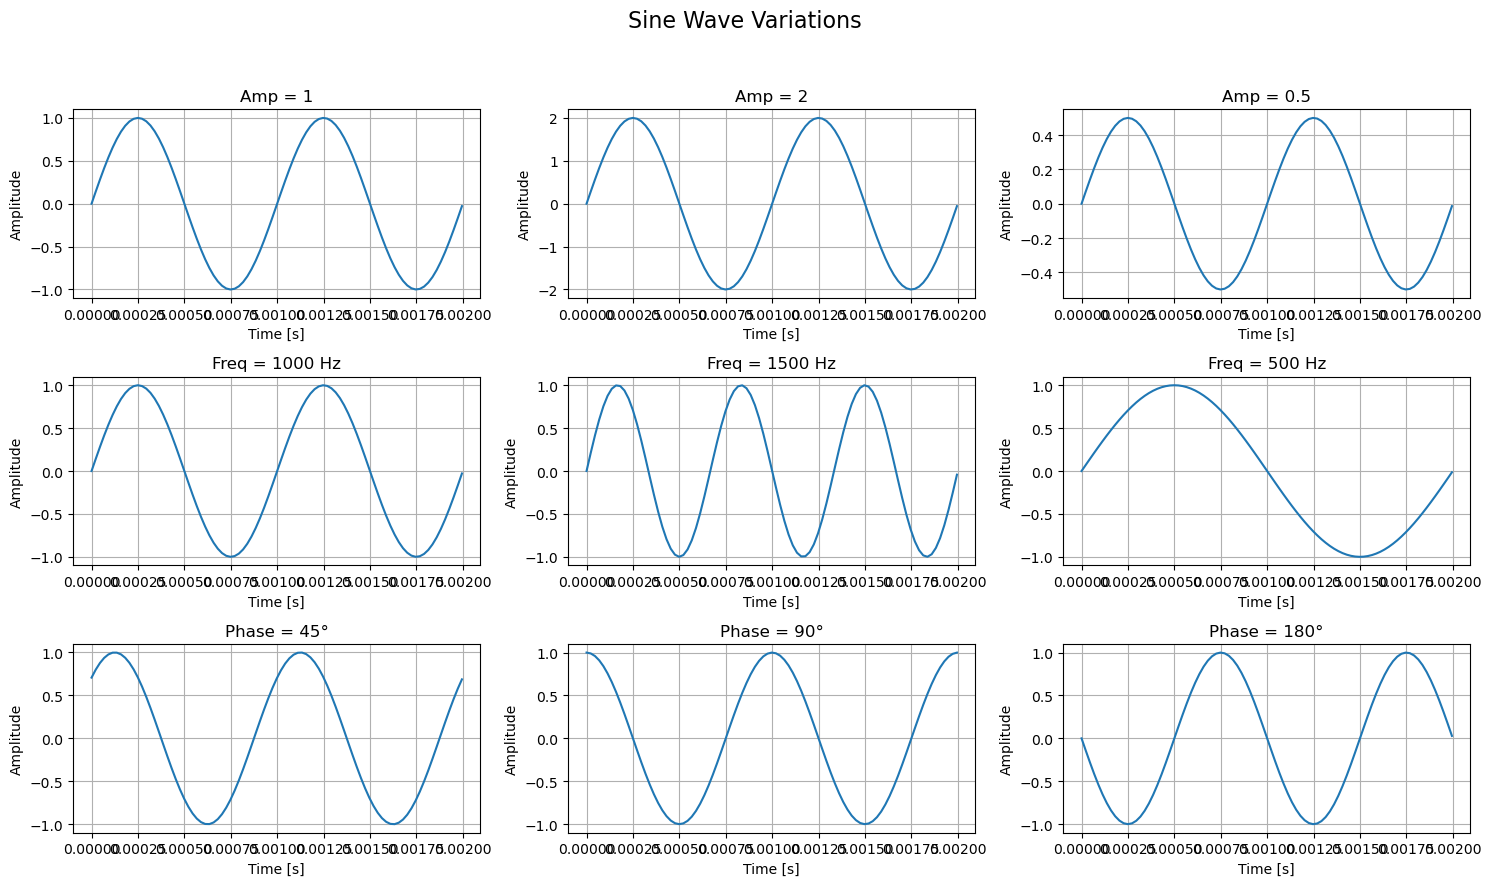

In [11]:
t, amp_1 = sg.sine(frequency=1000, amplitude=1, duration=0.002)
t, amp_2 = sg.sine(frequency=1000, amplitude=2, duration=0.002)
t, amp_3 = sg.sine(frequency=1000, amplitude=0.5, duration=0.002)

t, freq_1 = sg.sine(frequency=1000, amplitude=1, duration=0.002)
t, freq_2 = sg.sine(frequency=1500, amplitude=1, duration=0.002)
t, freq_3 = sg.sine(frequency=500, amplitude=1, duration=0.002)

t, phs_1 = sg.sine(frequency=1000, amplitude=1, phase_deg = 45, duration=0.002)
t, phs_2 = sg.sine(frequency=1000, amplitude=1, phase_deg = 90, duration=0.002)
t, phs_3 = sg.sine(frequency=1000, amplitude=1, phase_deg = 180, duration=0.002)

# Create a figure with 3 rows and 3 columns
fig, axes = plt.subplots(3, 3, figsize=(15, 9))
fig.suptitle("Sine Wave Variations", fontsize=16)

# Row 1: Amplitude variations
axes[0, 0].plot(t, amp_1); axes[0, 0].set_title("Amp = 1")
axes[0, 1].plot(t, amp_2); axes[0, 1].set_title("Amp = 2")
axes[0, 2].plot(t, amp_3); axes[0, 2].set_title("Amp = 0.5")

# Row 2: Frequency variations
axes[1, 0].plot(t, freq_1); axes[1, 0].set_title("Freq = 1000 Hz")
axes[1, 1].plot(t, freq_2); axes[1, 1].set_title("Freq = 1500 Hz")
axes[1, 2].plot(t, freq_3); axes[1, 2].set_title("Freq = 500 Hz")

# Row 3: Phase variations
axes[2, 0].plot(t, phs_1); axes[2, 0].set_title("Phase = 45°")
axes[2, 1].plot(t, phs_2); axes[2, 1].set_title("Phase = 90°")
axes[2, 2].plot(t, phs_3); axes[2, 2].set_title("Phase = 180°")

# Add labels
for ax in axes.flat:
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Amplitude")
    ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
plt.show()

## 4. Sampling

The physical world is continuous — a signal exists at every instant.  
A computer can only store a **finite list of numbers**.

Sampling is the process of reading a continuous signal at **regular intervals**.

$$x[n] = x(n \cdot T_s) \quad \text{where} \quad T_s = \frac{1}{f_s}$$

| Term | Symbol | Meaning |
|---|---|---|
| Sampling rate | $f_s$ | Snapshots per second (Hz) |
| Sampling period | $T_s = 1/f_s$ | Time between samples |
| Sample index | $n$ | Integer — 0, 1, 2, 3 ... |

The signal frequency and sampling rate are **independent**:
- $f$ describes the signal
- $f_s$ describes the observer

### Example
A 1 kHz sine wave sampled at 8000 Hz gives:
$$\text{samples per cycle} = \frac{f_s}{f} = \frac{8000}{1000} = 8$$

- Plotting a high-resolution continuous sine wave as a line, then overlaying the actual samples as dots using plt.plot(..., 'o'). 
- Using a low sampling rate like 1000 Hz on a 100 Hz signal so the dots are clearly visible and spaced apart.

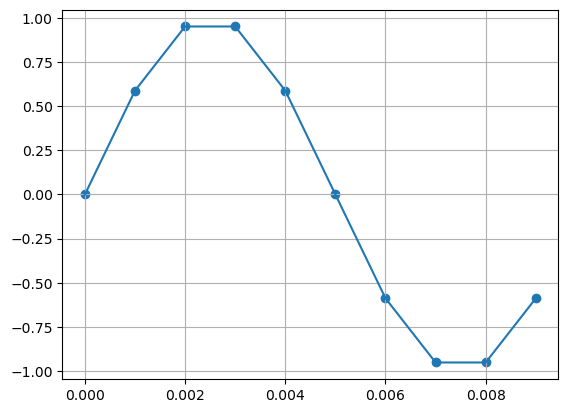

In [16]:
sg1 = SignalGenerator(fs=1000)
plt.scatter(t, sine)
plt.show()

t, sine = sg1.sine(frequency=100, duration=0.01)
plt.scatter(t, sine)
plt.plot(t, sine)
plt.grid()
plt.show()

## 5. Key Takeaways

- A signal is any quantity that varies with time
- A sine wave is fully described by amplitude, frequency, and phase: $x(t) = A \sin(2\pi f t + \varphi)$
- The physical world is continuous — computers work in discrete time
- Sampling reads the signal at regular intervals: $x[n] = x(n \cdot T_s)$
- Sampling rate $f_s$ and signal frequency $f$ are independent properties
- Higher $f_s$ = more samples per cycle = more faithful representation of the signal

### What's Next
Notebook 02 — Nyquist Theorem & Aliasing  
The Nyquist theorem tells us the minimum sampling rate — covered in notebook 02
How fast must we sample? What happens when we don't sample fast enough?